# Success Rate by MathML Length (4 Cases)


In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RESULT_SPECS = [
    {
        "case": "from-Nemeth (Braille -> MathML)",
        "path": "results/from-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "mathml_field": "expected",
        "braille_field": "test_input",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-Nemeth (MathML -> Braille)",
        "path": "results/to-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "mathml_field": "test_input",
        "braille_field": "expected",
        "prefer_normalized_section": False,
    },
    {
        "case": "from-UEB (Braille -> MathML)",
        "path": "results/from-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "mathml_field": "expected",
        "braille_field": "test_input",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-UEB (MathML -> Braille)",
        "path": "results/to-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "mathml_field": "test_input",
        "braille_field": "expected",
        "prefer_normalized_section": False,
    },
]

MATHML_CONTENT_BIN_SIZE = 5
BRAILLE_LENGTH_BIN_EDGES = [0, 3, 7, 12, 18, 30, 500]

In [2]:
def first_matching_idx(lines, predicate):
    for idx, line in enumerate(lines):
        if predicate(line):
            return idx
    return None


def parse_rows(filepath: str, prefer_normalized_section: bool):
    """Parse one file and return rows from either first or normalized section."""
    with open(filepath, "r", encoding="utf-8") as f:
        lines = [raw_line.strip() for raw_line in f]

    first_match_idx = first_matching_idx(lines, lambda s: s.startswith("# Match | Test Input") or s.startswith("Match | Test Input"))
    normalized_idx = first_matching_idx(lines, lambda s: s.startswith("# Normalized MathML") or s.startswith("Normalized MathML"))

    # Normalized MathML marker
    if prefer_normalized_section and normalized_idx is not None:
        start_idx = normalized_idx + 1
        section_used = 2
    else:
        start_idx = first_match_idx + 1
        section_used = 1

    # When using section 1 and a normalized marker exists later,
    # stop at that marker to avoid mixing both sections.
    if section_used == 1 and normalized_idx is not None and normalized_idx > start_idx:
        end_idx = normalized_idx
    else:
        end_idx = len(lines)

    rows = []
    for line in lines[start_idx:end_idx]:
        if not line or line.startswith("#"):
            continue
        if line.startswith("✓") or line.startswith("✗"):
            parts = line.split(" | ", 3)
            if len(parts) == 4:
                # Skip malformed pseudo-header rows that sometimes appear as "✗ | Test Input | Expected | ..."
                if parts[1] == "Test Input" and parts[2] == "Expected":
                    continue
                rows.append(
                    {
                        "is_success": parts[0] == "✓",
                        "test_input": parts[1],
                        "expected": parts[2],
                        "computed": parts[3],
                    }
                )

    return rows, section_used


def mathml_to_text_content(mathml: str) -> str:
    import re

    compact_xml = re.sub(r">\s+<", "><", mathml)
    root = ET.fromstring(compact_xml)
    return " ".join("".join(root.itertext()).split())


def build_dataframe(specs):
    rows = []

    for spec in specs:
        path = Path(spec["path"])
        selected_rows, section_used = parse_rows(str(path), spec["prefer_normalized_section"])

        if not selected_rows:
            raise ValueError(f"No parseable match rows found in: {path}")

        for result in selected_rows:
            mathml = result[spec["mathml_field"]]
            braille = result[spec["braille_field"]]
            mathml_text_content = mathml_to_text_content(mathml)

            rows.append(
                {
                    "case": spec["case"],
                    "file": str(path),
                    "section_used": section_used,
                    "is_success": result["is_success"],
                    "mathml": mathml,
                    "mathml_content": mathml_text_content,
                    "mathml_content_length": len(mathml_text_content),
                    "braille": braille,
                    "braille_length": len(braille),
                }
            )

    return pd.DataFrame(rows)


In [3]:
df = build_dataframe(RESULT_SPECS)

case_order = [spec["case"] for spec in RESULT_SPECS]

# Sanity check summary per file/case
summary_overall = (
    df.groupby(["case", "file", "section_used"], as_index=False)
      .agg(
          total=("is_success", "size"),
          success_rate=("is_success", "mean"),
          min_mathml_content_length=("mathml_content_length", "min"),
          max_mathml_content_length=("mathml_content_length", "max"),
          min_braille_length=("braille_length", "min"),
          max_braille_length=("braille_length", "max"),
      )
)
summary_overall["success_rate_pct"] = summary_overall["success_rate"] * 100
display(summary_overall)

,case,file,section_used,total,success_rate,min_mathml_content_length,max_mathml_content_length,min_braille_length,max_braille_length,success_rate_pct
0,from-Nemeth (Braille -> MathML),results/from-Nemeth-gemini-3-pro-preview-2473e...,2,200,0.740,1,112,2,155,74.0
1,from-UEB (Braille -> MathML),results/from-ueb-gemini-3-pro-preview-2352exs-...,2,200,0.900,1,112,2,174,90.0
2,to-Nemeth (MathML -> Braille),results/to-Nemeth-gemini-3-pro-preview-2473exs...,1,200,0.535,1,110,2,155,53.5
3,to-UEB (MathML -> Braille),results/to-ueb-gemini-3-pro-preview-2352exs-20...,1,200,0.690,1,112,2,174,69.0


In [4]:
# Fixed-width MathML content-length bins (size = 5), shared across all four cases
max_mathml_content_length = int(df["mathml_content_length"].max())
max_edge = ((max_mathml_content_length + MATHML_CONTENT_BIN_SIZE - 1) // MATHML_CONTENT_BIN_SIZE) * MATHML_CONTENT_BIN_SIZE
mathml_content_bin_edges = list(range(0, max_edge + 1, MATHML_CONTENT_BIN_SIZE))
if len(mathml_content_bin_edges) < 2:
    mathml_content_bin_edges = [0, MATHML_CONTENT_BIN_SIZE]

df["mathml_content_length_bin"] = pd.cut(
    df["mathml_content_length"],
    bins=mathml_content_bin_edges,
    include_lowest=True,
)
mathml_content_bin_order = list(df["mathml_content_length_bin"].cat.categories)

mathml_content_summary_by_bin = (
    df.groupby(["case", "mathml_content_length_bin"], observed=True)
      .agg(total=("is_success", "size"), success_rate=("is_success", "mean"))
      .reset_index()
)

mathml_content_full_index = pd.MultiIndex.from_product(
    [case_order, mathml_content_bin_order],
    names=["case", "mathml_content_length_bin"],
)
mathml_content_summary_by_bin = (
    mathml_content_summary_by_bin
    .set_index(["case", "mathml_content_length_bin"])
    .reindex(mathml_content_full_index)
    .reset_index()
)
mathml_content_summary_by_bin["success_rate_pct"] = mathml_content_summary_by_bin["success_rate"] * 100

mathml_content_bin_sizes = (
    df.groupby("mathml_content_length_bin", observed=False)
      .size()
      .reindex(mathml_content_bin_order, fill_value=0)
      .rename("count_total")
      .reset_index()
)

display(mathml_content_bin_sizes)
display(mathml_content_summary_by_bin)



,mathml_content_length_bin,count_total
0,"(-0.001, 5.0]",339
1,"(5.0, 10.0]",265
2,"(10.0, 15.0]",108
3,"(15.0, 20.0]",38
4,"(20.0, 25.0]",10
5,"(25.0, 30.0]",10
6,"(30.0, 35.0]",4
7,"(35.0, 40.0]",3
8,"(40.0, 45.0]",1
9,"(45.0, 50.0]",4


,case,mathml_content_length_bin,total,success_rate,success_rate_pct
0,from-Nemeth (Braille -> MathML),"(-0.001, 5.0]",84.0,0.797619,79.761905
1,from-Nemeth (Braille -> MathML),"(5.0, 10.0]",52.0,0.884615,88.461538
2,from-Nemeth (Braille -> MathML),"(10.0, 15.0]",32.0,0.656250,65.625000
3,from-Nemeth (Braille -> MathML),"(15.0, 20.0]",16.0,0.687500,68.750000
4,from-Nemeth (Braille -> MathML),"(20.0, 25.0]",2.0,0.500000,50.000000
...,...,...,...,...,...
87,to-UEB (MathML -> Braille),"(90.0, 95.0]",2.0,0.000000,0.000000
88,to-UEB (MathML -> Braille),"(95.0, 100.0]",1.0,0.000000,0.000000
89,to-UEB (MathML -> Braille),"(100.0, 105.0]",1.0,0.000000,0.000000
90,to-UEB (MathML -> Braille),"(105.0, 110.0]",1.0,0.000000,0.000000


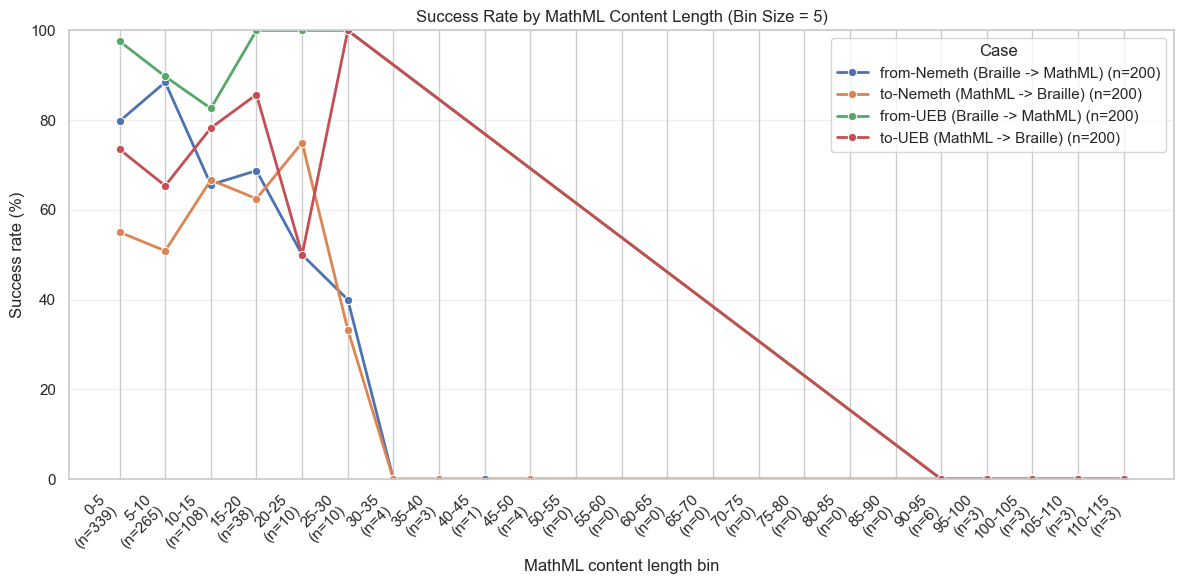

In [5]:
def format_interval(interval) -> str:
    left = int(round(interval.left))
    right = int(round(interval.right))
    return f"{left}-{right}"


x_positions = list(range(len(mathml_content_bin_order)))
bin_count_map = dict(zip(mathml_content_bin_sizes["mathml_content_length_bin"], mathml_content_bin_sizes["count_total"]))
x_labels = [f"{format_interval(interval)}\n(n={bin_count_map.get(interval, 0)})" for interval in mathml_content_bin_order]

n_per_case = df.groupby("case").size().to_dict()
mathml_plot_df = mathml_content_summary_by_bin.copy()
mathml_plot_df["x_pos"] = mathml_plot_df["mathml_content_length_bin"].map({interval: i for i, interval in enumerate(mathml_content_bin_order)})
mathml_plot_df["case_label"] = mathml_plot_df["case"].map(lambda c: f"{c} (n={n_per_case[c]})")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=mathml_plot_df,
    x="x_pos",
    y="success_rate_pct",
    hue="case_label",
    marker="o",
    linewidth=2,
    estimator=None,
    sort=False,
    ax=ax,
)

ax.set_title("Success Rate by MathML Content Length (Bin Size = 5)")
ax.set_xlabel("MathML content length bin")
ax.set_ylabel("Success rate (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case")
fig.tight_layout()
plt.show()



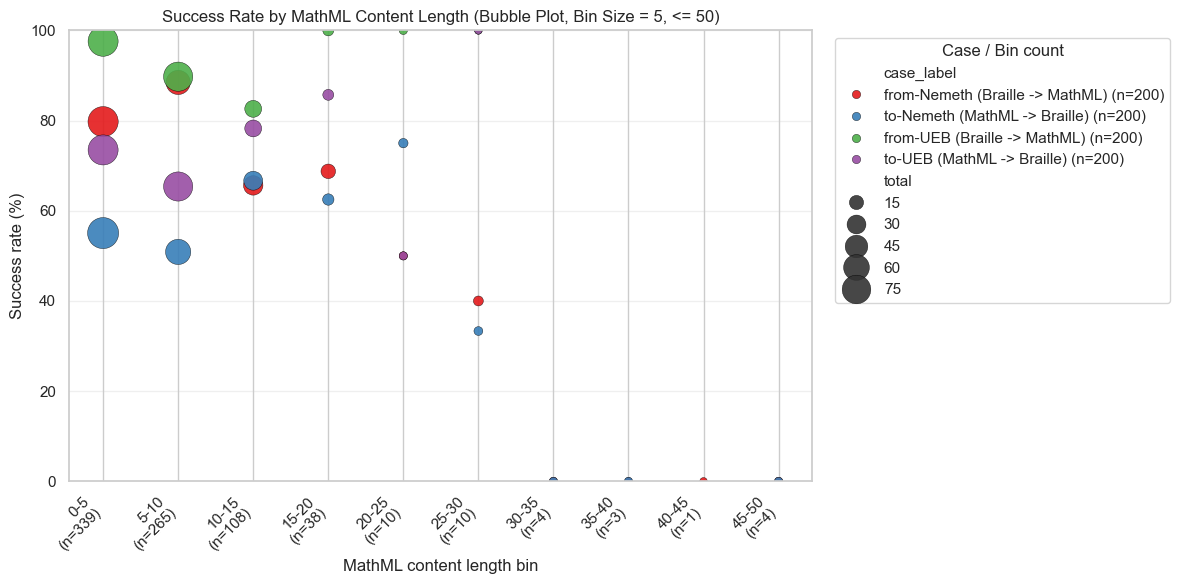

In [6]:
# Bubble scatter version of the same binned success-rate plot (cutoff at content length 50)
max_content_length_for_plot = 50
allowed_bins = [interval for interval in mathml_content_bin_order if interval.right <= max_content_length_for_plot]
allowed_bin_set = set(allowed_bins)

scatter_plot_df = mathml_content_summary_by_bin[
    mathml_content_summary_by_bin["mathml_content_length_bin"].isin(allowed_bin_set)
].copy()

x_pos_map = {interval: i for i, interval in enumerate(allowed_bins)}
scatter_plot_df["x_pos"] = scatter_plot_df["mathml_content_length_bin"].map(x_pos_map)
scatter_plot_df["case_label"] = scatter_plot_df["case"].map(lambda c: f"{c} (n={n_per_case[c]})")

x_positions_subset = list(range(len(allowed_bins)))
bin_count_map = dict(zip(mathml_content_bin_sizes["mathml_content_length_bin"], mathml_content_bin_sizes["count_total"]))
x_labels_subset = [f"{format_interval(interval)}\n(n={bin_count_map.get(interval, 0)})" for interval in allowed_bins]

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=scatter_plot_df,
    x="x_pos",
    y="success_rate_pct",
    hue="case_label",
    palette="Set1",
    size="total",
    sizes=(30, 500),
    alpha=0.9,
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
)

ax.set_title("Success Rate by MathML Content Length (Bubble Plot, Bin Size = 5, <= 50)")
ax.set_xlabel("MathML content length bin")
ax.set_ylabel("Success rate (%)")
ax.set_xticks(x_positions_subset)
ax.set_xticklabels(x_labels_subset, rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case / Bin count", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()



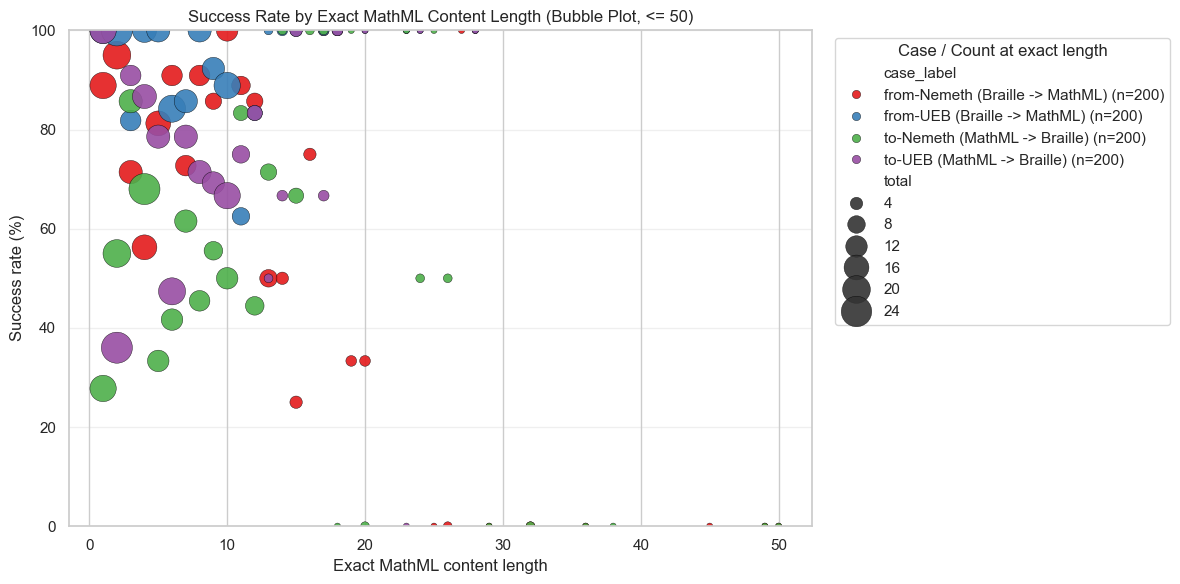

In [7]:
# Bubble scatter plot by exact MathML content length (no bins, clipped at 50)
exact_length_summary = (
    df.groupby(["case", "mathml_content_length"], as_index=False)
      .agg(total=("is_success", "size"), success_rate=("is_success", "mean"))
)
exact_length_summary = exact_length_summary[exact_length_summary["mathml_content_length"] <= 50].copy()
exact_length_summary["success_rate_pct"] = exact_length_summary["success_rate"] * 100
exact_length_summary["case_label"] = exact_length_summary["case"].map(lambda c: f"{c} (n={n_per_case[c]})")

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=exact_length_summary,
    x="mathml_content_length",
    y="success_rate_pct",
    hue="case_label",
    palette="Set1",
    size="total",
    sizes=(20, 500),
    alpha=0.9,
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
)

ax.set_title("Success Rate by Exact MathML Content Length (Bubble Plot, <= 50)")
ax.set_xlabel("Exact MathML content length")
ax.set_ylabel("Success rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case / Count at exact length", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

